   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
Species              False
dtype: bool
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000    

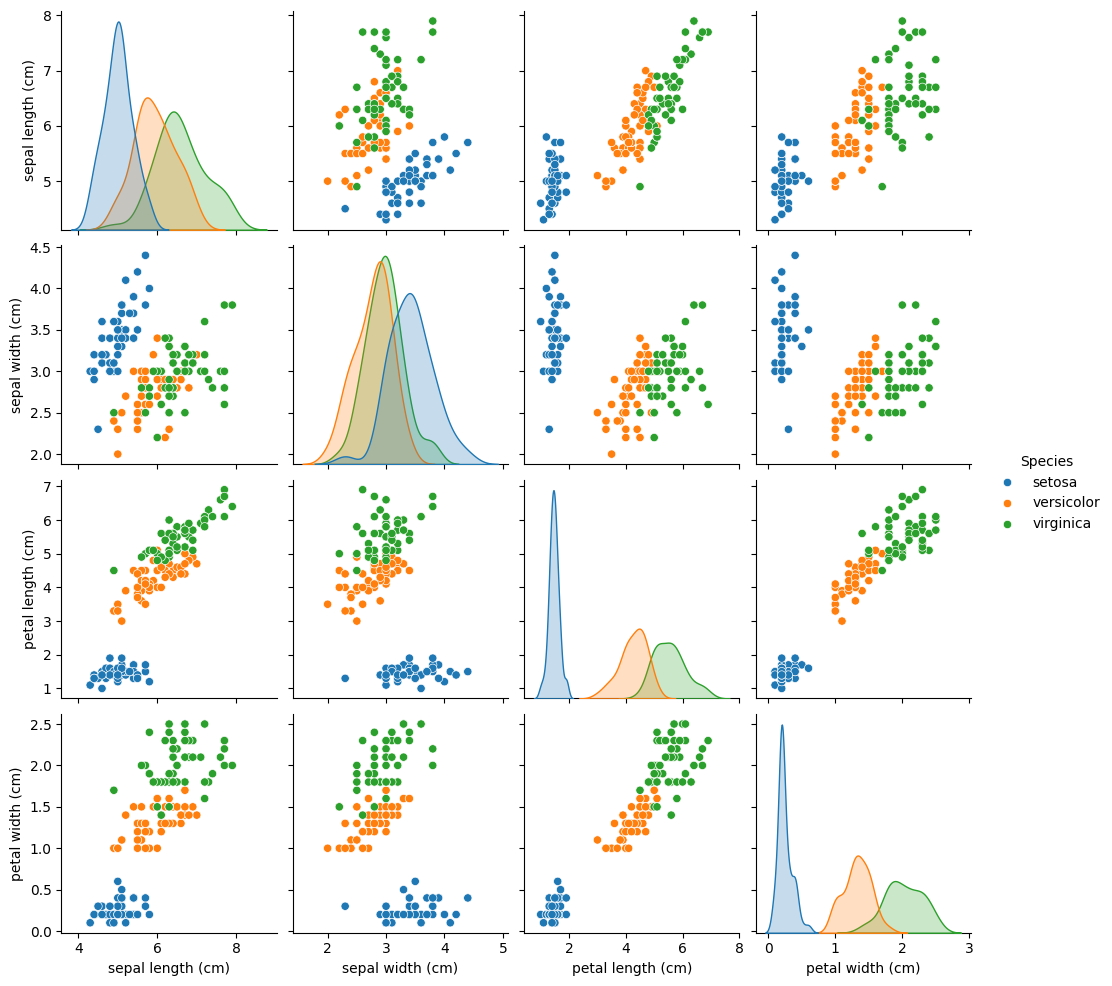

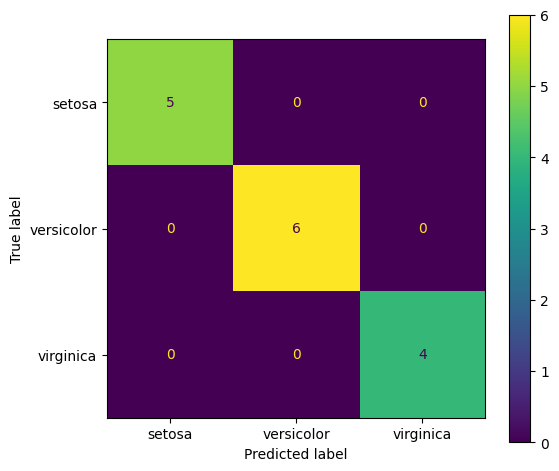

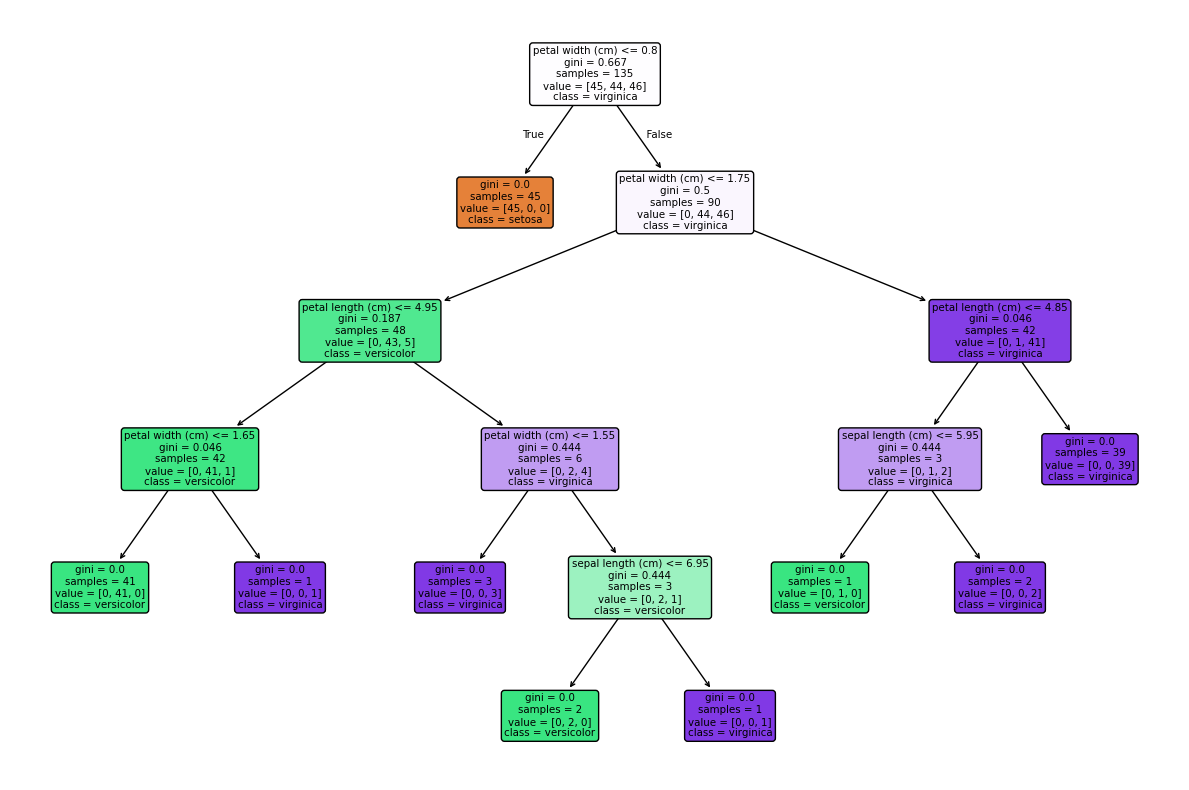

In [1]:
# Save the notebook as decision_tree_iris.ipynb

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load Iris dataset
iris = datasets.load_iris(as_frame=True)
iris_df = iris.frame
iris_df['Species'] = iris_df['target'].map(dict(enumerate(iris.target_names)))
iris_df = iris_df.drop(columns=['target'])

print(iris_df.head())

print(iris_df.isnull().any())
print(iris_df.describe())

sns.pairplot(iris_df, hue='Species')
plt.savefig("ex1_pairplot.png")

X = iris.data.values
y = iris_df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1
)

clf = tree.DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)

prediction = clf.predict(X_test)
print(prediction)

print(classification_report(y_test, prediction))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, ax=ax, colorbar=True
)
plt.tight_layout()
plt.savefig("ex1_confmatrix.png")

fig, ax = plt.subplots(figsize=(12, 8))
tree.plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    ax=ax
)
plt.tight_layout()
plt.savefig("ex1_tree.png")

sample = [[4.8, 2.9, 1.3, 0.2]]
res = clf.predict(sample)

print("The class predicted is --> " + str(res[0]))